In [1]:
import pandas as pd
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.analytics.db_connector import populate_financials, query_financials

df = pd.read_csv("../data/processed/cleaned/cleaned_data.csv")
print(f"Loaded {len(df)} rows")
print(df.columns.tolist())

Loaded 11 rows
['source', 'fetched_at', 'version', '_collection', 'data.make', 'data.model', 'data.year', 'data.recalls', 'data.file_name', 'data.document_type', 'data.source', 'data.extraction_timestamp', 'data.extraction_library', 'data.scraped_at', 'data.type', 'data.title', 'data.description', 'data.price', 'data.link', 'data.page', 'data.original_path', 'data.resized_path', 'data.thumbnail_path', 'data.webp_path', 'data.format', 'data.mode', 'data.width', 'data.height', 'data.file_size_kb', 'data.exif.file_name', 'data.exif.camera_make', 'data.exif.camera_model', 'data.exif.date_taken', 'data.exif.exposure_time', 'data.exif.aperture', 'data.exif.iso', 'data.exif.focal_length', 'data.exif.orientation', 'data.exif.gps', 'data.exif.extracted_at', 'data.processed_at', 'release_year']


In [2]:
populate_financials(df)

import sqlalchemy
engine = sqlalchemy.create_engine("mysql+pymysql://root:@localhost/automotive_tracker")
df_mysql = pd.read_sql("SELECT * FROM vehicle_financials WHERE year IS NOT NULL", engine)
print(f"MySQL rows: {len(df_mysql)}")
df_mysql.head()

MySQL rows: 143


,id,make,model,year,recall_count,source,version,collection_name,release_year,fetched_at
0,1,Audi,A4,2020,0,test,1.0,raw_recalls,2026,2026-03-23 22:57:44.926
1,2,Skoda,OCTAVIA,2020,0,nhtsa_api,1.0,raw_recalls,2026,2026-03-23 23:02:08.429
2,3,Unknown,UNKNOWN,2020,0,pdf_extraction,1.0,raw_recalls,2026,2026-03-29 20:52:52.608
3,4,Unknown,UNKNOWN,2020,0,word_extraction,1.0,raw_recalls,2026,2026-03-29 21:02:26.591
4,5,Unknown,UNKNOWN,2020,0,excel_extraction,1.0,raw_recalls,2026,2026-03-29 21:05:48.985


In [3]:
df_clean = df[~df["data.make"].isin(["Unknown", "UNKNOWN"])].copy()
print(f"Rows after filtering Unknown: {len(df_clean)}")
df_clean["data.make"].value_counts()

Rows after filtering Unknown: 3


data.make
Audi     2
Skoda    1
Name: count, dtype: int64

In [4]:
from src.analytics.data_combiner import merge_dataframes, compare_join_types, concat_dataframes

df_mongo_style = df_clean[["data.make", "data.model", "data.year", "source", "release_year"]].copy()
df_mongo_style.columns = ["make", "model", "year", "source", "release_year"]

df_mysql_clean = df_mysql[df_mysql["make"] != "Unknown"].copy()

join_counts = compare_join_types(df_mongo_style, df_mysql_clean, on="make")
print("Join type row counts:")
for join_type, count in join_counts.items():
    print(f"  {join_type}: {count} rows")

Join type row counts:
  inner: 65 rows
  left: 65 rows
  right: 65 rows
  outer: 65 rows


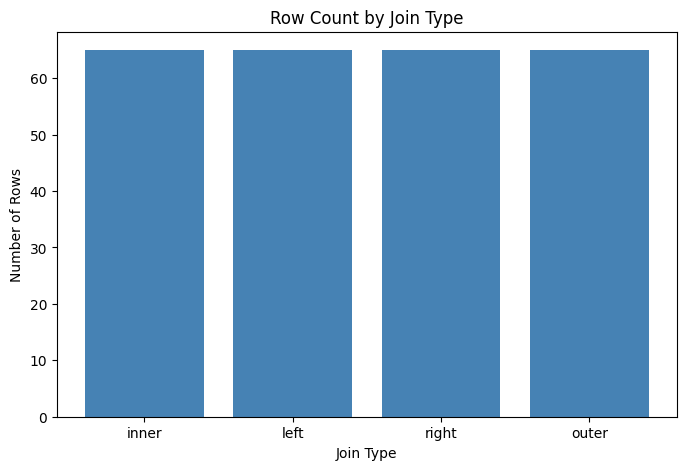

Chart saved.


In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(join_counts.keys(), join_counts.values(), color="steelblue")
plt.title("Row Count by Join Type")
plt.xlabel("Join Type")
plt.ylabel("Number of Rows")
plt.savefig("../data/processed/analytics/join_comparison.png")
plt.show()
print("Chart saved.")

In [7]:
print(df_combined.columns.tolist())

['make', 'model_x', 'year_x', 'source_x', 'release_year_x', 'id', 'model_y', 'year_y', 'recall_count', 'source_y', 'version', 'collection_name', 'release_year_y', 'fetched_at']


In [8]:
from src.analytics.pivot_builder import wide_to_long, build_pivot_table, build_crosstab

df_combined = merge_dataframes(df_mongo_style, df_mysql_clean, on="make", how="inner")

long_df = wide_to_long(
    df_combined,
    id_vars=["make", "model_x", "year_x"],
    value_vars=["recall_count", "version", "release_year_x"]
)
print(f"Long format rows: {len(long_df)}")
long_df.head()

Long format rows: 195


,make,model_x,year_x,metric,value
0,Audi,A4,2020.0,recall_count,0.0
1,Audi,A4,2020.0,recall_count,128.0
2,Audi,A4,2020.0,recall_count,0.0
3,Audi,A4,2020.0,recall_count,128.0
4,Audi,A4,2020.0,recall_count,0.0


In [10]:
pivot = build_pivot_table(
    df_combined,
    index="make",
    columns="source_x",
    values="recall_count",
    aggfunc="mean",
    margins=True
)
print(pivot)
pivot.to_csv("../data/processed/analytics/pivot_make_source.csv")
print("Pivot saved.")

source_x  dynamic_scraping  nhtsa_api  test   All
make                                             
Audi                  64.0        NaN  64.0  64.0
Skoda                  NaN        0.0   NaN   0.0
All                   64.0        0.0  64.0  51.2
Pivot saved.


In [11]:
ct = build_crosstab(df_combined, "make", "source_x")
print(ct)

source_x  dynamic_scraping  nhtsa_api  test
make                                       
Audi                    26          0    26
Skoda                    0         13     0


In [12]:
from src.analytics.aggregator import genre_summary, yearly_trends, top_n_per_group

summary = genre_summary(df_combined, group_col="make", value_col="recall_count")
print(summary)
summary.to_csv("../data/processed/analytics/genre_analysis.csv", index=False)
print("Saved genre_analysis.csv")

    make  mean_recalls  sum_recalls  count  median_recalls
0   Audi          64.0         3328     52            64.0
1  Skoda           0.0            0     13             0.0
Saved genre_analysis.csv


   year_x  total_recalls  avg_recalls  count
0  2020.0           3328         51.2     65


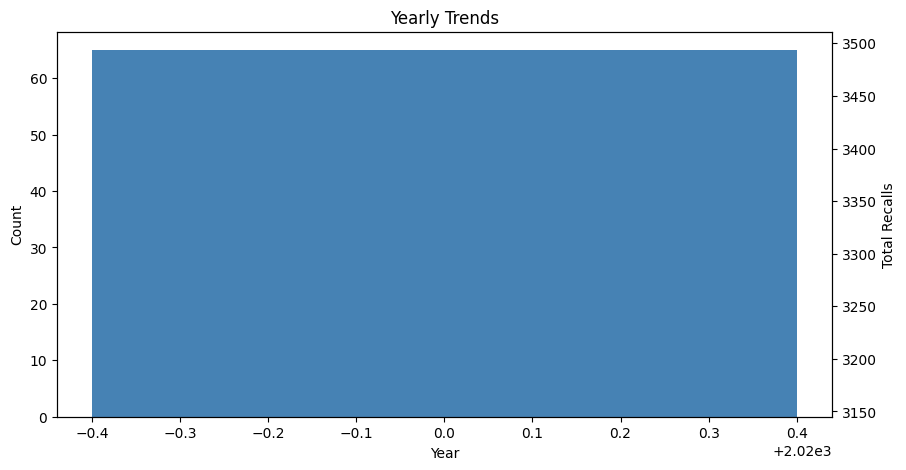

Saved yearly_trends.png


In [13]:
trends = yearly_trends(df_combined, year_col="year_x", value_col="recall_count")
print(trends)
trends.to_csv("../data/processed/analytics/yearly_trends.csv", index=False)

import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(trends["year_x"], trends["count"], color="steelblue", label="Count")
ax1.set_xlabel("Year")
ax1.set_ylabel("Count")
ax2 = ax1.twinx()
ax2.plot(trends["year_x"], trends["total_recalls"], color="red", label="Total Recalls")
ax2.set_ylabel("Total Recalls")
plt.title("Yearly Trends")
plt.savefig("../data/processed/analytics/yearly_trends.png")
plt.show()
print("Saved yearly_trends.png")

In [14]:
top3 = top_n_per_group(df_combined, group_col="make", value_col="recall_count", n=3)
print(top3[["make", "model_x", "year_x", "recall_count"]])

     make  model_x  year_x  recall_count
1    Audi       A4  2020.0           128
3    Audi       A4  2020.0           128
5    Audi       A4  2020.0           128
26  Skoda  OCTAVIA  2020.0             0
27  Skoda  OCTAVIA  2020.0             0
28  Skoda  OCTAVIA  2020.0             0


/Users/elmedin.karisiksystemverification.com/Documents/private/Automotive-Industry-Tracker/src/analytics/aggregator.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = df.groupby(group_col, group_keys=False).apply(top_n)


In [15]:
from src.analytics.time_series import parse_dates, extract_date_components, monthly_time_series, yearly_time_series, rolling_averages

df_combined, valid, missing = parse_dates(df_combined, date_col="fetched_at")
print(f"Valid dates: {valid}, Missing: {missing}")

Valid dates: 65, Missing: 0


In [16]:
df_combined = extract_date_components(df_combined, date_col="fetched_at")
print(df_combined[["make", "fetched_at", "year", "month", "weekday", "quarter"]].head())

   make              fetched_at  year  month  weekday  quarter
0  Audi 2026-03-23 22:57:44.926  2026      3        0        1
1  Audi 2026-04-02 16:24:55.801  2026      4        3        2
2  Audi 2026-03-23 22:57:44.926  2026      3        0        1
3  Audi 2026-04-02 16:24:55.801  2026      4        3        2
4  Audi 2026-03-23 22:57:44.926  2026      3        0        1


In [17]:
monthly = monthly_time_series(df_combined, date_col="fetched_at", value_col="recall_count")
yearly = yearly_time_series(df_combined, date_col="fetched_at", value_col="recall_count")
print("Monthly:\n", monthly)
print("Yearly:\n", yearly)

Monthly:
 fetched_at
2026-03-31       0
2026-04-30    3328
Freq: ME, Name: recall_count, dtype: int64
Yearly:
 fetched_at
2026-12-31    3328
Freq: YE-DEC, Name: recall_count, dtype: int64


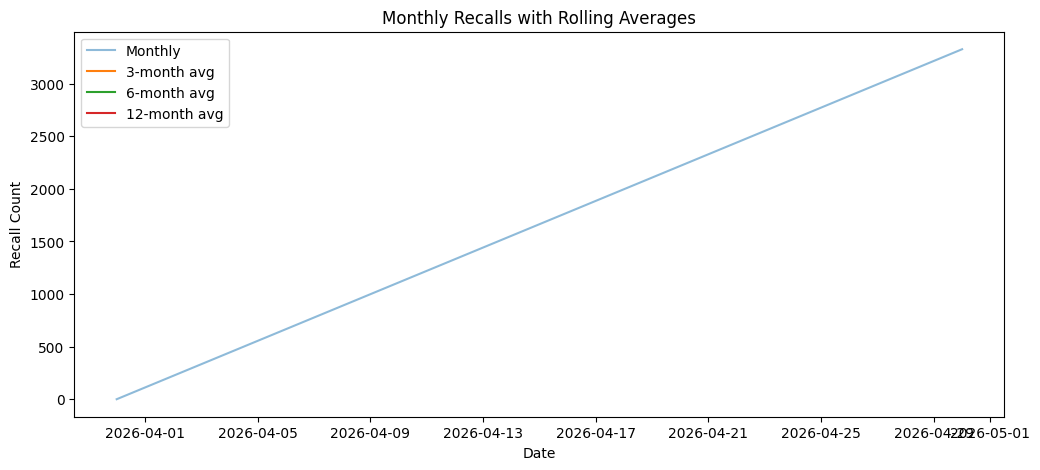

Saved rolling_revenue.png


In [18]:
import matplotlib.pyplot as plt

rolling = rolling_averages(monthly, windows=[3, 6, 12])

plt.figure(figsize=(12, 5))
plt.plot(rolling.index, rolling["value"], label="Monthly", alpha=0.5)
plt.plot(rolling.index, rolling["rolling_3"], label="3-month avg")
plt.plot(rolling.index, rolling["rolling_6"], label="6-month avg")
plt.plot(rolling.index, rolling["rolling_12"], label="12-month avg")
plt.title("Monthly Recalls with Rolling Averages")
plt.xlabel("Date")
plt.ylabel("Recall Count")
plt.legend()
plt.savefig("../data/processed/analytics/rolling_revenue.png")
plt.show()
print("Saved rolling_revenue.png")

In [22]:
from src.analytics.mongo_pipeline import get_mongo_collection, run_aggregation_pipeline

collection = get_mongo_collection(db_name="automotive_pipeline", collection_name="raw_recalls")
df_mongo_agg = run_aggregation_pipeline(collection)
print(df_mongo_agg)

   total_recalls  avg_version  count        make
0            210          1.0     84  Volkswagen
1            132          1.0     45        Audi
2              0          1.0      1       Skoda


In [23]:
from src.analytics.insight_reporter import run_all_questions, recall_rate_by_make

run_all_questions(df_combined, df_mongo_agg)

ANALYTICAL FINDINGS

1. Top makes by total recalls:
         make  total_recalls
0  Volkswagen            210
1        Audi            132
2       Skoda              0

2. Recall rate by make:
         make  recall_rate
1        Audi     2.933333
0  Volkswagen     2.500000
2       Skoda     0.000000

3. Yearly vehicle volume:
   year_x   make  count
0  2020.0   Audi     52
1  2020.0  Skoda     13

4. Data source distribution:
             source  count
0              test     26
1  dynamic_scraping     26
2         nhtsa_api     13


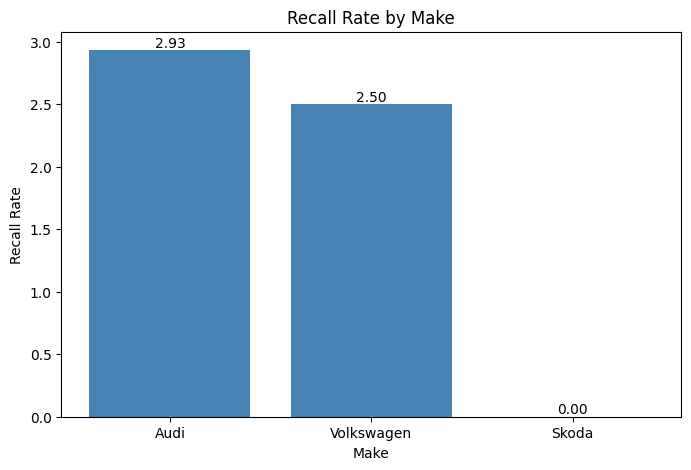

Saved genre_roi.png


In [24]:
import matplotlib.pyplot as plt

roi_df = recall_rate_by_make(df_mongo_agg)

plt.figure(figsize=(8, 5))
bars = plt.bar(roi_df["make"], roi_df["recall_rate"], color="steelblue")
for bar, val in zip(bars, roi_df["recall_rate"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.2f}", ha="center", va="bottom")
plt.title("Recall Rate by Make")
plt.xlabel("Make")
plt.ylabel("Recall Rate")
plt.savefig("../data/processed/analytics/genre_roi.png")
plt.show()
print("Saved genre_roi.png")

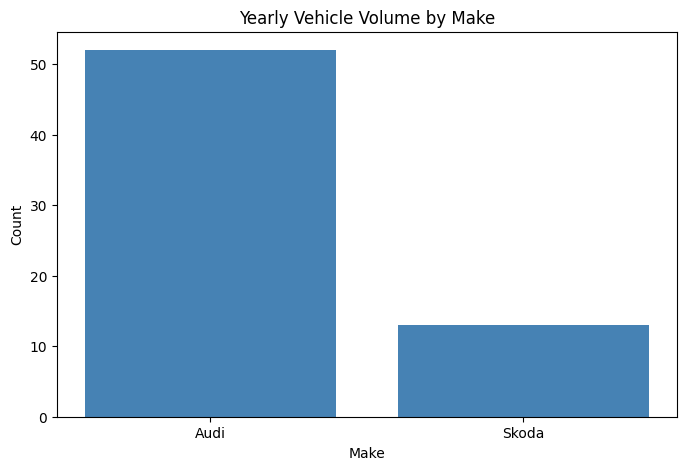

Saved yearly_volume.png


In [26]:
import matplotlib.pyplot as plt
from src.analytics.insight_reporter import yearly_volume, source_distribution, top_makes_by_recalls

vol = yearly_volume(df_combined)
plt.figure(figsize=(8, 5))
plt.bar(vol["make"], vol["count"], color="steelblue")
plt.title("Yearly Vehicle Volume by Make")
plt.xlabel("Make")
plt.ylabel("Count")
plt.savefig("../data/processed/analytics/yearly_volume.png")
plt.show()
print("Saved yearly_volume.png")

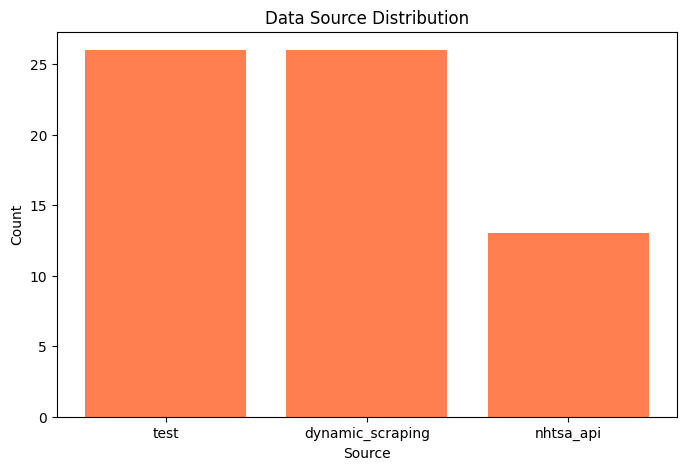

Saved source_distribution.png


In [27]:
from src.analytics.insight_reporter import source_distribution

dist = source_distribution(df_combined)
plt.figure(figsize=(8, 5))
plt.bar(dist["source"], dist["count"], color="coral")
plt.title("Data Source Distribution")
plt.xlabel("Source")
plt.ylabel("Count")
plt.savefig("../data/processed/analytics/source_distribution.png")
plt.show()
print("Saved source_distribution.png")

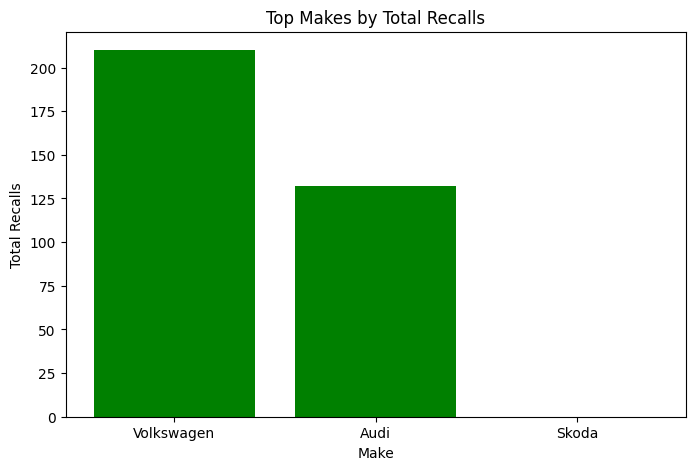

Saved top_makes_recalls.png


In [28]:
top_makes = top_makes_by_recalls(df_mongo_agg)
plt.figure(figsize=(8, 5))
plt.bar(top_makes["make"], top_makes["total_recalls"], color="green")
plt.title("Top Makes by Total Recalls")
plt.xlabel("Make")
plt.ylabel("Total Recalls")
plt.savefig("../data/processed/analytics/top_makes_recalls.png")
plt.show()
print("Saved top_makes_recalls.png")